In [1]:
import warnings; warnings.filterwarnings(action='ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from binance import Client

In [2]:
client = Client()
def get_tickers():
    tickers = []
    for info in client.futures_mark_price():
        ticker = info['symbol']
        if ticker[-4:] == "USDT":
            tickers.append(info['symbol'])
    return tickers

def get_sample(ticker, start_date="1 Jan, 2021"):
    klines = np.array(client.futures_historical_klines(ticker, Client.KLINE_INTERVAL_1DAY, start_date))
    sample = pd.DataFrame(klines.reshape(-1, 12), dtype=float, columns=['datetime',
                                                                        'open', 
                                                                        'high', 
                                                                        'low', 
                                                                        'close', 
                                                                        'volume', 
                                                                        'close time', 
                                                                        'quote asset volume, number of trades', 
                                                                        'number of trades',
                                                                        'taker buy base asset volume', 
                                                                        'taker buy quote asset volume', 
                                                                        'ignore'])
    sample['datetime'] = pd.to_datetime(sample['datetime'], unit='ms')
    sample.set_index('datetime', inplace=True)
    sample = sample[['open', 'high', 'low', 'close', 'volume']].copy()
    return sample

In [3]:
tickers = get_tickers()

# drop coins with length < 200
for ticker in tickers:
    sample = get_sample(ticker, start_date="1 Mar, 2021")
    if len(sample) < 200: tickers.remove(ticker)
    else: continue

In [4]:
# define preprocessing functions
def add_momentum(sample, period=20):
    df = sample.copy()
    df[f'mom{period}'] = (df['close'] - df.shift(period)['close'])/df.shift(period)['close']
    sample[f'mom{period}'] = df[f'mom{period}']; del df
    return sample

def add_noise(sample, period=20):
    df = sample.copy()
    df['noise'] = 1. - abs(df['close'] - df['open'])/(df['high'] - df['low'])
    df[f'noise{period}'] = df['noise'].rolling(period).mean()
    sample[f'noise{period}'] = df[f"noise{period}"]; del df
    return sample

def add_percentB(sample, period=20):
    df = sample.copy()
    df['center'] = df['close'].rolling(period).mean()
    df['upper'] = df['center'] + 2.*df['close'].rolling(period).std()
    df['lower'] = df['center'] - 2.*df['close'].rolling(period).std()
    df['percentB'] = (df['close'] - df['lower'])/(df['upper'] - df['lower'])
    sample['percentB'] = df['percentB']; del df
    return sample

def add_RSI(sample, period=14):
    df = sample.copy()
    df['TP'] = (df['high'] + df['low'] + df['close'])/3.
    df['U'] = 0.; df['D'] = 0.
    for idx in df.index:
        if df.shift(1).loc[idx, 'TP'] < df.loc[idx, 'TP']:
            df.loc[idx, 'U'] = df.loc[idx, 'TP']
        else:
            df.loc[idx, 'D'] = df.loc[idx, 'TP']
    df['AU'] = df['U'].rolling(period).mean()
    df['AD'] = df['D'].rolling(period).mean()
    df['RSI'] = df['AU']/(df['AU']+df['AD'])
    sample['TP'] = df['TP']
    sample['RSI'] = df['RSI']; del df
    return sample

In [9]:
# Test will be based on different days of momentum
samples = dict()
for ticker in tickers:
    sample = get_sample(ticker, start_date="1 Apr, 2020")   # at least 21 coins are possible
    
    # preprocess
    sample = add_momentum(sample, period=7)
    sample = add_momentum(sample, period=14)
    sample = add_momentum(sample, period=20)
    sample = add_momentum(sample, period=21)
    sample = add_momentum(sample, period=60)
    sample = add_RSI(sample)
    sample['reward'] = 1. + sample['close'].pct_change()
    sample['total_reward'] = sample['reward'].cumprod()
    sample.dropna(inplace=True)
    
    samples[ticker] = sample.copy(); del sample
reference = samples['BTCUSDT']

In [13]:
# 1. choose top 21 trading coins
# 2. sort in indicator
# 3. compare top 5 / bottom 5 momentum coins
def inspect_indicator(indicator):
    top5 = samples['BTCUSDT'][['close']].copy()
    top5['number'] = top5.index.map(mdates.date2num)
    top5['reward'] = 1. 
    top5['total_reward'] = 1.
    bottom5 = top5.copy()

    for idx in top5.index[:-1]:
        # select 21 highest volume coins
        volumes = dict()
        for ticker in tickers:
            try:
                volumes[ticker] = samples[ticker].loc[idx, 'TP']*samples[ticker].loc[idx, 'volume']
            except:
                continue
        top21v = dict(sorted(volumes.items(), key=(lambda x: x[1]), reverse=True)[:21])
    
        # sort in indicator order
        temp = dict()
        for ticker in top21v.keys():
            try:
                temp[ticker] = samples[ticker].loc[idx, indicator]
            except:
                print(ticker)
        temp = dict(sorted(temp.items(), key=(lambda x: x[1]), reverse=True))
    
        # estimate reward for top/bottom 5
        reward_top = 0.; reward_bottom = 0.
        for coin in list(temp.keys())[:5]:
            this_reward = samples[coin].shift(-1).loc[idx, 'reward'] - 0.003
            reward_top += 0.2*this_reward
        for coin in list(temp.keys())[-5:]:
            this_reward = samples[coin].shift(-1).loc[idx, 'reward'] - 0.003
            reward_bottom += 0.2*this_reward
    
        top5.loc[idx, 'reward'] = reward_top
        bottom5.loc[idx, 'reward'] = reward_bottom
        
    total_reward = 1.
    for idx in top5.index:
        total_reward *= top5.loc[idx, 'reward']
        top5.loc[idx, 'total_reward'] = total_reward
    total_reward = 1.
    for idx in bottom5.index:
        total_reward *= bottom5.loc[idx, 'reward']
        bottom5.loc[idx, 'total_reward'] = total_reward
    
    return (top5, bottom5)

In [16]:
def evaluate(book, title=""):
    # CAGR, MDD, Volatility, Sharpe
    CAGR = book['total_reward'].iloc[-1]**(365/len(book.index)) - 1.

    historical_max = book['total_reward'].cummax()
    daily_drawdown = book['total_reward']/historical_max - 1.
    historical_dd = daily_drawdown.cummin()
    MDD = historical_dd.min()
    
    VOL = np.std(book['reward'])*np.sqrt(365.)
    Sharpe = (np.mean(book['reward'])/np.std(book['reward'])*np.sqrt(365.))

    # win-loose ratio
    win = 0; loose = 0
    for idx in book.index:
        if book.loc[idx, 'reward'] > 1.:
            win += 1
        else:
            loose += 1
    win_loose_ratio = win/(win+loose)

    print(f"==== {title} ====")
    print(f"Accumulated Returns: {(book['total_reward'].iloc[-1]-1.)*100:.2f}%")
    print(f"CAGR: {CAGR*100:.2f}%")
    print(f"MDD: {MDD*100:.2f}%")
    print(f"VOL: {VOL*100:.2f}%")
    print(f"Sharpe: {Sharpe*100:.2f}%")
    print(f"win-loose ratio: {win_loose_ratio*100:.2f}%")
    print()

In [17]:
top5, bottom5 = inspect_indicator("mom7")
evaluate(top5, "momentum 7 days - top5")
evaluate(bottom5, "momentum 7 days - bottom5")

top5, bottom5 = inspect_indicator("mom14")
evaluate(top5, "momentum 14 days - top5")
evaluate(bottom5, "momentum 14 days - bottom5")

top5, bottom5 = inspect_indicator("mom21")
evaluate(top5, "momentum 21 days - top5")
evaluate(bottom5, "momentum 21 days - bottom5")

top5, bottom5 = inspect_indicator("mom60")
evaluate(top5, "momentum 60 days - top5")
evaluate(bottom5, "momentum 60 days - bottom5")


==== momentum 7 days - top5 ====
Accumulated Returns: 2257.90%
CAGR: 471.16%
MDD: -75.74%
VOL: 131.21%
Sharpe: 28015.63%
win-loose ratio: 52.87%

==== momentum 7 days - bottom5 ====
Accumulated Returns: -69.14%
CAGR: -47.71%
MDD: -84.34%
VOL: 113.60%
Sharpe: 32131.14%
win-loose ratio: 50.76%

==== momentum 14 days - top5 ====
Accumulated Returns: 1387.57%
CAGR: 343.05%
MDD: -79.05%
VOL: 133.74%
Sharpe: 27468.61%
win-loose ratio: 53.02%

==== momentum 14 days - bottom5 ====
Accumulated Returns: -65.01%
CAGR: -43.96%
MDD: -84.83%
VOL: 110.20%
Sharpe: 33124.21%
win-loose ratio: 50.45%

==== momentum 21 days - top5 ====
Accumulated Returns: 2578.94%
CAGR: 512.80%
MDD: -74.10%
VOL: 131.42%
Sharpe: 27976.50%
win-loose ratio: 52.87%

==== momentum 21 days - bottom5 ====
Accumulated Returns: -78.48%
CAGR: -57.13%
MDD: -86.75%
VOL: 109.38%
Sharpe: 33347.27%
win-loose ratio: 50.60%

==== momentum 60 days - top5 ====
Accumulated Returns: 177.91%
CAGR: 75.69%
MDD: -76.55%
VOL: 122.00%
Sharpe: 3002

### Conclusion
- 7, 20 days momentums showed the best result

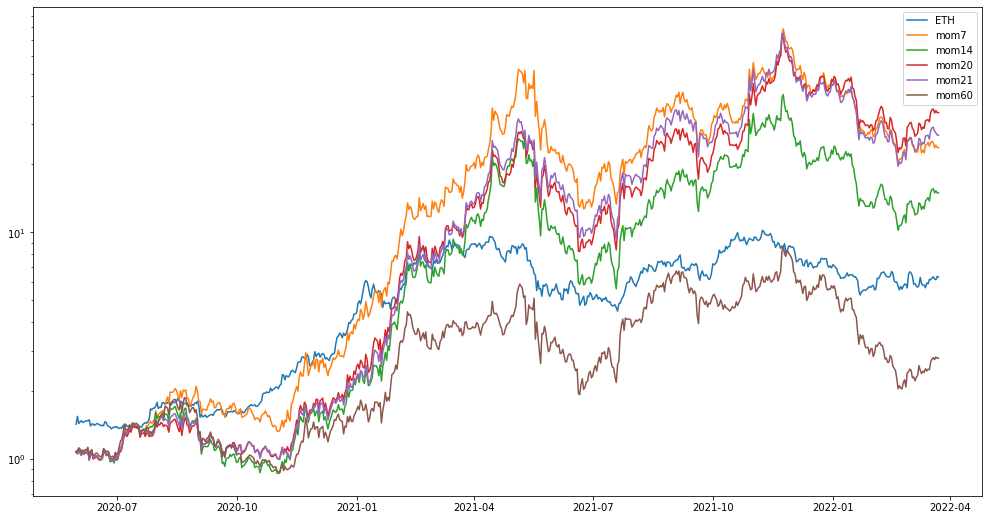

In [25]:
mom7, _ = inspect_indicator("mom7")
mom14, _ = inspect_indicator("mom14")
mom20, _ = inspect_indicator("mom20")
mom21, _ = inspect_indicator("mom21")
mom60, _ = inspect_indicator("mom60")


plt.figure(figsize=(17, 9))
plt.yscale('log')
plt.plot(reference.index, reference.total_reward, label='ETH')
plt.plot(mom7.index, mom7.total_reward, label="mom7")
plt.plot(mom14.index, mom14.total_reward, label="mom14")
plt.plot(mom20.index, mom20.total_reward, label="mom20")
plt.plot(mom21.index, mom21.total_reward, label="mom21")
plt.plot(mom60.index, mom60.total_reward, label="mom60")

plt.legend(loc='best')
plt.show()